# Project - Zuber

## 1 - Importing libraries

In [217]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from IPython.display import display
import seaborn as sns

## 2 - Importing Dataframes

In [218]:
df_1 = pd.read_csv('../data/moved_project_sql_result_01.csv')
df_4 = pd.read_csv('../data/moved_project_sql_result_04.csv')
df_7 = pd.read_csv('../data/moved_project_sql_result_07.csv')

## 3 - Data Description and Display

### 3.1 - Data Description

Description of dataframes

Dataframe 1 

company_name = taxi company.  
trips_amount = the number of rides for each taxi company from November 15 to 16, 2017.

Dataframe 4 

dropoff_location_name = Chicago neighborhoods where the races ended.  
average_trips = the average number of trips that ended in each neighborhood in November 2017.

Dataframe 7 

start_ts = date and time of collection.  
weather_conditions = weather conditions at the time the race started.  
duration_seconds = running duration in seconds.

### 3.2 - Data Display

#### 3.2.1 - Dataframe 1

In [219]:
# Printing df_1 information
print("DataFrame 1")
print(df_1.head())
print(df_1.info())

DataFrame 1
                      company_name  trips_amount
0                        Flash Cab         19558
1        Taxi Affiliation Services         11422
2                 Medallion Leasin         10367
3                       Yellow Cab          9888
4  Taxi Affiliation Service Yellow          9299
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   company_name  64 non-null     object
 1   trips_amount  64 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 1.1+ KB
None


#### 3.2.2 - Dataframe 4

In [220]:
# Printing df_4 information
print("DataFrame 4")
print(df_4.head())
print(df_4.info())

DataFrame 4
  dropoff_location_name  average_trips
0                  Loop   10727.466667
1           River North    9523.666667
2         Streeterville    6664.666667
3             West Loop    5163.666667
4                O'Hare    2546.900000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   dropoff_location_name  94 non-null     object 
 1   average_trips          94 non-null     float64
dtypes: float64(1), object(1)
memory usage: 1.6+ KB
None


#### 3.2.3 - Dataframe 7

In [221]:
# Printing df_7 information
df_7['start_ts'] = pd.to_datetime(df_7['start_ts'])
print("DataFrame 7")
print(df_7.head())
print(df_7.info())

DataFrame 7
             start_ts weather_conditions  duration_seconds
0 2017-11-25 16:00:00               Good            2410.0
1 2017-11-25 14:00:00               Good            1920.0
2 2017-11-25 12:00:00               Good            1543.0
3 2017-11-04 10:00:00               Good            2512.0
4 2017-11-11 07:00:00               Good            1440.0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1068 entries, 0 to 1067
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   start_ts            1068 non-null   datetime64[ns]
 1   weather_conditions  1068 non-null   object        
 2   duration_seconds    1068 non-null   float64       
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 25.2+ KB
None


## 4 - Data Exploratory Analysis

### 4.1 - Identify the top 10 neighborhoods in terms of travel destinations based on average travel.

In [222]:
top_10_neighborhoods = df_4.sort_values(by='average_trips', ascending=False).head(10).round(2)
print("Top 10 neighborhoods by average travels")
display(top_10_neighborhoods)

Top 10 neighborhoods by average travels


,dropoff_location_name,average_trips
0,Loop,10727.47
1,River North,9523.67
2,Streeterville,6664.67
3,West Loop,5163.67
4,O'Hare,2546.90
5,Lake View,2420.97
6,Grant Park,2068.53
7,Museum Campus,1510.00
8,Gold Coast,1364.23
9,Sheffield & DePaul,1259.77


### 4.2 - Let’s create a bar graph to visualize the number of rides of taxi companies.

In [223]:
df_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   company_name  64 non-null     object
 1   trips_amount  64 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 1.1+ KB


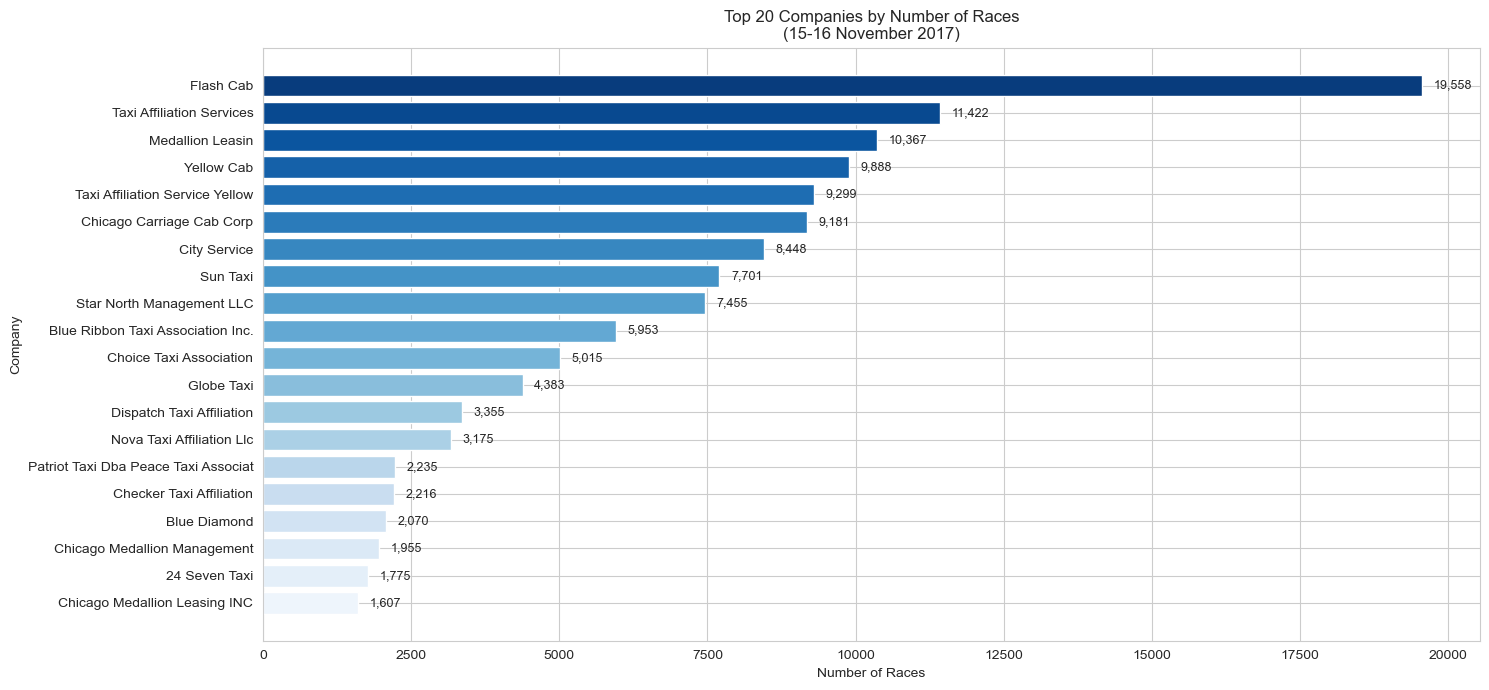

In [224]:
top20 = (df_1.groupby('company_name')['trips_amount'].sum().sort_values(ascending=False).head(20))

plt.figure(figsize=(15, 7))
sns.set_style("whitegrid")

bars = plt.barh(top20.index, top20.values, color=sns.color_palette("Blues_r", 20))

for bar in bars:
    width = bar.get_width()
    plt.text(width + max(top20.values)*0.01,bar.get_y() + bar.get_height()/2,f"{int(width):,}",va='center', fontsize=9)

plt.title("Top 20 Companies by Number of Races\n(15-16 November 2017)")
plt.xlabel("Number of Races")
plt.ylabel("Company")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### 4.3 - Select top 10 neighborhoods by average of races

In [225]:
df_4.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   dropoff_location_name  94 non-null     object 
 1   average_trips          94 non-null     float64
dtypes: float64(1), object(1)
memory usage: 1.6+ KB


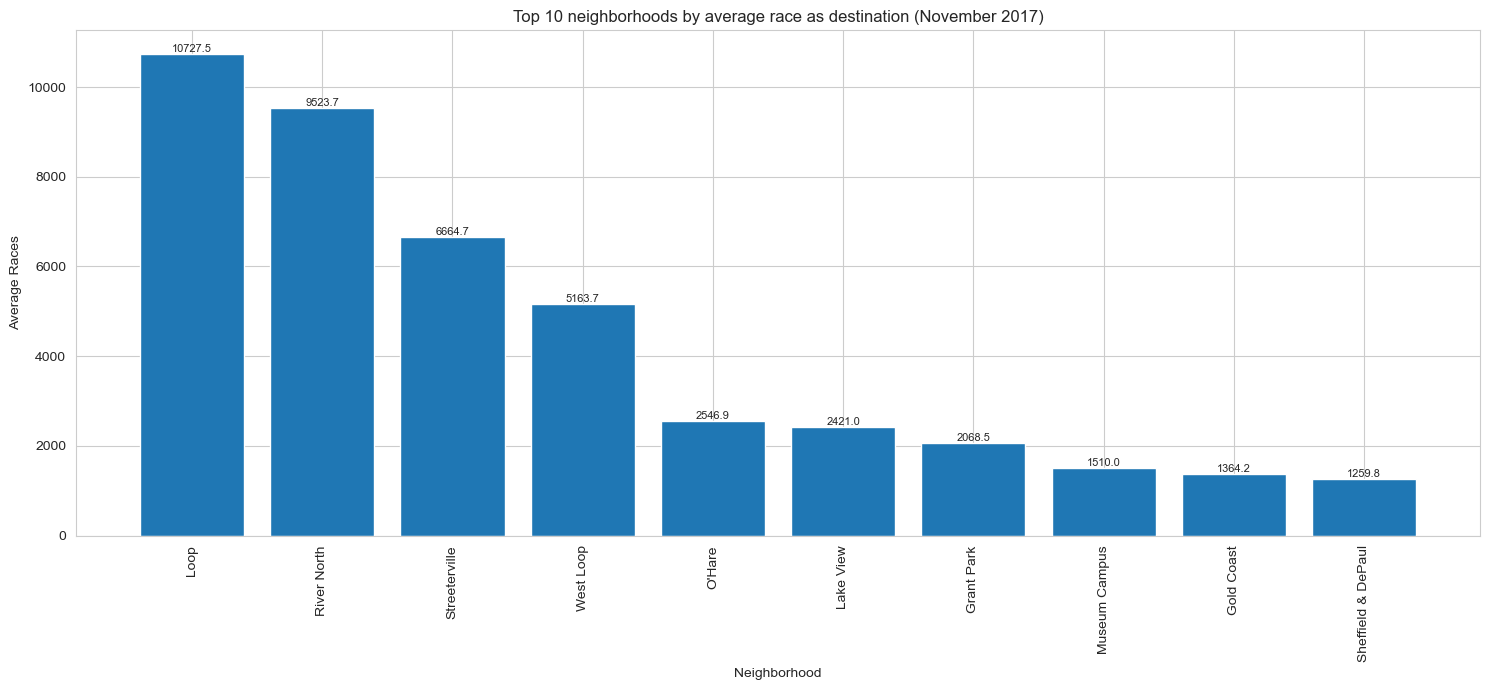

In [226]:
top10 = df_4.sort_values('average_trips', ascending=False).head(10)

plt.figure(figsize=(15, 7))
bars = plt.bar(top10['dropoff_location_name'], top10['average_trips'])

for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2,bar.get_height(),f'{bar.get_height():.1f}',ha='center', va='bottom', fontsize=8)

plt.xticks(rotation=90)
plt.title('Top 10 neighborhoods by average race as destination (November 2017)')
plt.xlabel('Neighborhood')
plt.ylabel('Average Races')
plt.tight_layout()
plt.show()

Based on the generated charts and tables, we can identify that the most popular taxi companies are 'Flash Cab' leading with the highest number of rides, followed by 'Taxi Affiliation Services' and 'Medallion Leasin'.  
In addition, the most popular neighborhoods as travel destinations are 'Loop' leading with the highest average of races, followed by 'River North' and 'Streeterville'.

### 5 - Hypothesis test

In [227]:
# Create column with day of week (Saturday = 5)
df_7['weekday'] = df_7['start_ts'].dt.weekday

# Filter Saturdays only
df_sat = df_7[df_7['weekday'] == 5]

# Separate groups: rainy vs non-wet
rain = df_sat[df_sat['weather_conditions'] == 'Bad']
no_rain = df_sat[df_sat['weather_conditions'] == 'Good']
rain_durations = rain['duration_seconds'] / 60
no_rain_durations = no_rain['duration_seconds'] / 60

In [228]:
alpha = 0.05

results = stats.ttest_ind(rain_durations, no_rain_durations, equal_var=False)
print("p-value:", results.pvalue)

if results.pvalue < alpha:
    print("Reject H0: the average trip duration CHANGES on rainy Saturdays.")
else:
    print("Fail to reject H0: there is no evidence of a change in the average trip duration.")

p-value: 6.738994326109027e-12
Reject H0: the average trip duration CHANGES on rainy Saturdays.


Average trip duration from the Loop to O'Hare Airport on rainy Saturdays
Hypotheses

H₀: The average trip duration is the same on rainy and non-rainy Saturdays.

H₁: The average trip duration is different on rainy Saturdays.

Significance Level

α = 0.05

Method

A two-sample independent t-test (Welch’s t-test) was applied because we are comparing the mean of two independent groups (rainy vs. non-rainy), and the variances may be different.

Decision Rule

If p-value < 0.05 → reject H₀ (the average duration changes).

If p-value ≥ 0.05 → fail to reject H₀ (there is no evidence of a change).

### 6 - Conclusion

The integrated analysis between travel data and weather conditions allowed to identify important relationships between weather, location and duration of races in Chicago.
The dataframes created throughout the project - containing travel information, weather and junctions between both - made it possible to filter and compare specific segments, such as runs that leave the loop and arrive at O'Hare Airport.

The results showed that:

On rainy Saturdays, the races had a longer average duration, suggesting direct impact of weather conditions on traffic and travel time.

The combination of joins between weather and travel tables allowed to analyze only the races with valid weather data, ensuring consistency.

The use of filters based on location IDs, weekdays and weather conditions demonstrated how different factors influence the operation of races.

Overall, the project highlights the importance of integrating multiple data sources to understand urban and operational patterns. The final dataframes provide a solid foundation for deeper analysis, including predictions, optimizations, and identification of travel behavior anomalies.